In [2]:
!pip install -q -U transformers datasets accelerate evaluate jiwer soundfile peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 94.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.8 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numb

In [14]:
!pip install -q \
    "numpy==1.26.4" \
    "torch==2.2.2" \
    "torchvision==0.17.2" \
    "torchaudio==2.2.2" \
    "transformers==4.44.2" \
    "accelerate==0.33.0" \
    "peft==0.12.0" \
    "datasets==2.21.0" \
    "evaluate==0.4.1" \
    --force-reinstall --no-cache-dir

print("Xong — restart kernel ngay")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 238.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 262.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 301.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 329.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 268.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 234.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 175.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 161.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 221.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 203.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 240.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━

In [6]:
!pip install torchao --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.2 MB/s eta 0:00:00a 0:00:01


In [8]:
import os
import torch
import evaluate
import numpy as np

from datasets import load_dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

from peft import (
    LoraConfig,
    get_peft_model,
    PeftModel,
    TaskType
)

In [9]:
import shutil, os

# Xóa HuggingFace cache
shutil.rmtree("/root/.cache/huggingface", ignore_errors=True)

# Kiểm tra disk còn bao nhiêu
total, used, free = shutil.disk_usage("/kaggle/working")
print(f"Free: {free/1e9:.1f}GB")

Free: 20.9GB


In [10]:
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [16]:
# ============================================================
# CONFIG: Chunk-based Continual Training cho Whisper LoRA
# ViMER Project - Vietnamese Speech Emotion Recognition
# ============================================================
#
# HƯỚNG DẪN SỬ DỤNG:
#   - Chunk 1: CHUNK_ID = 1, RESUME_FROM_HUB = False
#   - Chunk 2+: CHUNK_ID += 1, RESUME_FROM_HUB = True
#   - Mỗi chunk dùng LEARNING_RATE giảm dần (xem bảng bên dưới)
#
# LEARNING RATE SCHEDULE:
#   Chunk 1 → 1e-4   (học từ đầu, lr cao)
#   Chunk 2 → 5e-5   (tiếp tục, lr giảm)
#   Chunk 3 → 2e-5   (ổn định, lr thấp)
#   Chunk 4+ → 1e-5  (fine-tune nhẹ)
# ============================================================

# ── Chunk control ─────────────────────────────────────────
CHUNK_ID         = 5          # ← THAY ĐỔI MỖI LẦN TRAIN
CHUNK_SIZE       = 5000     # streaming mode: 10k an toàn với Kaggle disk
CHUNK_OFFSET     = (CHUNK_ID - 1) * CHUNK_SIZE   # tự tính offset

RESUME_FROM_HUB  = True      # Chunk 1: False | Chunk 2+: True

# ── Learning rate theo chunk ──────────────────────────────
_LR_SCHEDULE = {1: 1e-4, 2: 5e-5, 3: 2e-5}
LEARNING_RATE = _LR_SCHEDULE.get(CHUNK_ID, 3e-5)  # chunk 4+ dùng 1e-5

# ── Model & Data ──────────────────────────────────────────
MODEL_NAME     = "openai/whisper-small"
DATASET_NAME   = "NhutP/VietSpeech"
LANGUAGE       = "Vietnamese"
TASK           = "transcribe"
SAMPLE_RATE    = 16000
MAX_DURATION   = 15            # giây, cắt audio quá dài

# ── Sampling ──────────────────────────────────────────────
TRAIN_SAMPLES  = CHUNK_SIZE    # 50k mỗi chunk
EVAL_SAMPLES   = 500         # tăng lên để eval chính xác hơn
EVAL_OFFSET    = 45000

# Replay buffer: mix 10% data cũ vào chunk mới (từ chunk 2 trở đi)
REPLAY_RATIO   = 0.1           # 10% data cũ
REPLAY_SAMPLES = int(TRAIN_SAMPLES * REPLAY_RATIO) if CHUNK_ID > 1 else 0
SHUFFLE_BUFFER = 300  # buffer nhỏ thôi, đủ shuffle mà không tốn RAM

# ── Training ──────────────────────────────────────────────
BATCH_SIZE     = 4
GRAD_ACCUM     = 4             # effective batch = 16
WARMUP_STEPS   = 120           # 10% của MAX_STEPS
MAX_STEPS      = 1200         # phù hợp với 10k samples, effective batch=16
FP16           = True          # bật fp16 để tiết kiệm VRAM trên T4

# ── Logging & Saving ──────────────────────────────────────
LOGGING_STEPS    = 25
EVAL_STEPS       = 200
SAVE_STEPS       = 200
SAVE_TOTAL_LIMIT = 3           # chỉ giữ 2 checkpoint gần nhất

# ── LoRA ──────────────────────────────────────────────────
LORA_R              = 16
LORA_ALPHA          = 32
LORA_DROPOUT        = 0.05
LORA_TARGET_MODULES = [        # mở rộng so với config cũ
    "q_proj",
    "v_proj",
    "k_proj",
    "out_proj",
]

# ── Hub ───────────────────────────────────────────────────
PUSH_TO_HUB  = True            # LUÔN BẬT để tránh mất checkpoint
HUB_MODEL_ID = "qdovan03/whisper-small-vi-lora-asr"
HUB_STRATEGY = "every_save"    # push mỗi lần save

# ── Output ────────────────────────────────────────────────
OUTPUT_DIR     = f"/kaggle/working/whisper-vimer-lora-chunk{CHUNK_ID}"
BEST_MODEL_DIR = f"/kaggle/working/whisper-vimer-lora-best-chunk{CHUNK_ID}"

# ── Seed ──────────────────────────────────────────────────
SEED = 42

# ── Sanity check ──────────────────────────────────────────
print("=" * 50)
print(f"  CHUNK ID       : {CHUNK_ID}")
print(f"  CHUNK OFFSET   : {CHUNK_OFFSET:,} → {CHUNK_OFFSET + TRAIN_SAMPLES:,}")
print(f"  TRAIN SAMPLES  : {TRAIN_SAMPLES:,}")
print(f"  REPLAY SAMPLES : {REPLAY_SAMPLES:,}")
print(f"  LEARNING RATE  : {LEARNING_RATE}")
print(f"  MAX STEPS      : {MAX_STEPS:,}")
print(f"  RESUME HUB     : {RESUME_FROM_HUB}")
print(f"  PUSH TO HUB    : {PUSH_TO_HUB}")
print(f"  OUTPUT DIR     : {OUTPUT_DIR}")
print(f"  EVAL OFFSET    : {EVAL_OFFSET:,} → {EVAL_OFFSET + EVAL_SAMPLES:,}")
print("=" * 50)

  CHUNK ID       : 5
  CHUNK OFFSET   : 20,000 → 25,000
  TRAIN SAMPLES  : 5,000
  REPLAY SAMPLES : 500
  LEARNING RATE  : 3e-05
  MAX STEPS      : 1,200
  RESUME HUB     : True
  PUSH TO HUB    : True
  OUTPUT DIR     : /kaggle/working/whisper-vimer-lora-chunk5
  EVAL OFFSET    : 45,000 → 45,500


In [12]:
# ============================================================
# LOAD MODEL + LORA — Hỗ trợ resume từ HuggingFace Hub
# ============================================================

from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

# ── Login HuggingFace ──────────────────────────────────────
secrets = UserSecretsClient()
hf_token = secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("✓ HuggingFace login OK")

✓ HuggingFace login OK


In [21]:
# ── Load Processor ─────────────────────────────────────────
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language=LANGUAGE,
    task=TASK,
)
print("✓ Processor loaded")

# ── Load base model ────────────────────────────────────────
base_model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

# Fix config cho Whisper training/generation
base_model.config.use_cache = False
base_model.generation_config.language = LANGUAGE.lower()
base_model.generation_config.task = TASK
base_model.generation_config.forced_decoder_ids = None
base_model.generation_config.suppress_tokens = None

# ── Load Model ─────────────────────────────────────────────
if RESUME_FROM_HUB:
    print(f"  Resuming from Hub: {HUB_MODEL_ID}")

    model = PeftModel.from_pretrained(
        base_model,
        HUB_MODEL_ID,
        is_trainable=True,
    )

    print(f"✓ LoRA model loaded from Hub (chunk {CHUNK_ID})")

else:
    print(f"  Starting fresh from: {MODEL_NAME}")

    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES,
        bias="none",
        task_type=TaskType.SEQ_2_SEQ_LM,
    )

    model = get_peft_model(base_model, lora_config)
    print("✓ LoRA applied to base model")

# ── Final training fixes ───────────────────────────────────
model.config.use_cache = False

# Chỉ cần nếu bạn bật gradient_checkpointing=True.
# Không phải fix chính cho lỗi input_ids.
model.enable_input_require_grads()

# ── Trainable params ───────────────────────────────────────
model.print_trainable_parameters()

✓ Processor loaded


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

  Resuming from Hub: qdovan03/whisper-small-vi-lora-asr
✓ LoRA model loaded from Hub (chunk 5)
trainable params: 3,538,944 || all params: 245,273,856 || trainable%: 1.4429


In [17]:
# ============================================================
# LOAD DATASET — Streaming → Materialize regular Dataset
# Fix shuffle/skip + eval nhanh + tránh IterableDataset trong Trainer
# ============================================================

from datasets import load_dataset, Audio, Dataset, concatenate_datasets
from datasets.iterable_dataset import IterableDataset as HFIterableDataset

import os
import gc
import shutil
import pyarrow as pa
import pyarrow.parquet as pq

# Nếu bạn chưa khai báo CHUNK_SIZE thì mặc định = TRAIN_SAMPLES
if "CHUNK_SIZE" not in globals():
    CHUNK_SIZE = TRAIN_SAMPLES

if "REPLAY_SAMPLES" not in globals():
    REPLAY_SAMPLES = 0

# ============================================================
# LOAD STREAMING DATASET
# ============================================================

print(f"Loading dataset streaming: {DATASET_NAME}")
raw_dataset = load_dataset(DATASET_NAME, split="train", streaming=True)
print("✓ Dataset stream ready")

# Check column thực tế
sample = next(iter(raw_dataset))
actual_columns = list(sample.keys())
print(f"  Columns: {actual_columns}")

# Detect transcript column
TRANSCRIPT_COL = None
for candidate in ["transcription", "sentence", "text", "transcript"]:
    if candidate in actual_columns:
        TRANSCRIPT_COL = candidate
        break

if TRANSCRIPT_COL is None:
    raise ValueError(f"Không tìm thấy transcript column. Columns: {actual_columns}")

print(f"  Transcript column: {TRANSCRIPT_COL}")

REMOVE_COLS = [c for c in actual_columns if c in ["audio", TRANSCRIPT_COL]]


# ============================================================
# PREPROCESS FUNCTION
# Dataset lưu audio_array + labels
# input_features sẽ tạo trong data_collator
# ============================================================

def prepare_dataset(batch):
    try:
        audio = batch["audio"]
        text = batch[TRANSCRIPT_COL]

        if text is None or len(str(text).strip()) == 0:
            return {
                "audio_array": None,
                "labels": None,
            }

        max_samples = MAX_DURATION * SAMPLE_RATE
        audio_array = audio["array"][:max_samples]

        # Bỏ audio quá ngắn
        if len(audio_array) < int(SAMPLE_RATE * 0.5):
            return {
                "audio_array": None,
                "labels": None,
            }

        labels = processor.tokenizer(str(text)).input_ids

        return {
            "audio_array": audio_array.tolist(),
            "labels": labels,
        }

    except Exception:
        return {
            "audio_array": None,
            "labels": None,
        }


# ============================================================
# HELPER: STREAM → PARQUET → REGULAR DATASET
# ============================================================

def materialize_stream(stream, label="dataset", save_path=None, flush_size=200):
    print(f"  Materializing {label}...")

    if save_path is None:
        save_path = f"/kaggle/working/{label.replace(' ', '_')}"

    if os.path.exists(save_path):
        shutil.rmtree(save_path)

    os.makedirs(save_path, exist_ok=True)
    parquet_path = f"{save_path}/data.parquet"

    writer = None
    count = 0
    skipped = 0

    buffer_audio = []
    buffer_labels = []

    def flush():
        nonlocal writer, buffer_audio, buffer_labels

        if len(buffer_audio) == 0:
            return

        table = pa.table({
            "audio_array": buffer_audio,
            "labels": buffer_labels,
        })

        if writer is None:
            writer = pq.ParquetWriter(parquet_path, table.schema)

        writer.write_table(table)

        buffer_audio = []
        buffer_labels = []

    for item in stream:
        if item.get("audio_array") is None or item.get("labels") is None:
            skipped += 1
            continue

        buffer_audio.append(item["audio_array"])
        buffer_labels.append(item["labels"])
        count += 1

        if count % flush_size == 0:
            flush()
            print(f"    {count:,} samples...", end="\r")

    flush()

    if writer is not None:
        writer.close()
    else:
        raise ValueError(f"{label} không có sample hợp lệ nào.")

    ds = Dataset.from_parquet(parquet_path)

    print(f"  ✓ {label}: {len(ds):,} samples | skipped {skipped:,}")
    return ds


# ============================================================
# EVAL DATASET — take cố định samples đầu, không skip xa
# ============================================================

print(f"\nEval dataset: take first {EVAL_SAMPLES:,}")

eval_stream = (
    raw_dataset
    .skip(EVAL_OFFSET)
    .take(EVAL_SAMPLES)
    .cast_column("audio", Audio(sampling_rate=SAMPLE_RATE))
    .map(
        prepare_dataset,
        remove_columns=REMOVE_COLS,
    )
)

eval_dataset = materialize_stream(
    eval_stream,
    label="eval",
    save_path="/kaggle/working/eval_dataset"
)


# ============================================================
# TRAIN DATASET — skip trước, shuffle sau
# ============================================================

# Eval lấy samples đầu, nên train phải bắt đầu sau eval
CHUNK_OFFSET = (CHUNK_ID - 1) * CHUNK_SIZE

print(f"\nChunk {CHUNK_ID}: skip {CHUNK_OFFSET:,} → shuffle → take {TRAIN_SAMPLES:,}")

main_stream = (
    raw_dataset
    .skip(CHUNK_OFFSET)
    .shuffle(seed=SEED + CHUNK_ID, buffer_size=SHUFFLE_BUFFER)
    .take(TRAIN_SAMPLES)
    .cast_column("audio", Audio(sampling_rate=SAMPLE_RATE))
    .map(
        prepare_dataset,
        remove_columns=REMOVE_COLS,
    )
)

main_ds = materialize_stream(
    main_stream,
    label="main chunk",
    save_path=f"/kaggle/working/main_chunk_{CHUNK_ID}"
)


# ============================================================
# REPLAY BUFFER — chỉ lấy từ các chunk cũ
# ============================================================

if REPLAY_SAMPLES > 0 and CHUNK_ID > 1:
    old_pool_size = (CHUNK_ID - 1) * CHUNK_SIZE
    effective_replay = min(REPLAY_SAMPLES, old_pool_size)

    print(f"\nReplay buffer: old pool {old_pool_size:,} → take {effective_replay:,}")

    replay_stream = (
        raw_dataset
        .skip(EVAL_SAMPLES)
        .take(old_pool_size)
        .shuffle(seed=SEED + 999, buffer_size=SHUFFLE_BUFFER)
        .take(effective_replay)
        .cast_column("audio", Audio(sampling_rate=SAMPLE_RATE))
        .map(
            prepare_dataset,
            remove_columns=REMOVE_COLS,
        )
    )

    replay_ds = materialize_stream(
        replay_stream,
        label="replay buffer",
        save_path=f"/kaggle/working/replay_buffer_{CHUNK_ID}"
    )

    train_dataset = concatenate_datasets([main_ds, replay_ds])
    train_dataset = train_dataset.shuffle(seed=SEED)

    print(
        f"  ✓ Combined train: {len(train_dataset):,} samples "
        f"= {len(main_ds):,} main + {len(replay_ds):,} replay"
    )

    del replay_ds
    gc.collect()

else:
    train_dataset = main_ds
    print("  No replay for this chunk")


# Cleanup
del main_ds
gc.collect()


# ============================================================
# SUMMARY + VERIFY
# ============================================================

print(f"\n{'='*55}")
print(f"  Train samples : {len(train_dataset):,}")
print(f"  Eval samples  : {len(eval_dataset):,}")
print(f"  Train type    : {type(train_dataset)}")
print(f"  Eval type     : {type(eval_dataset)}")
print(f"{'='*55}")

assert not isinstance(train_dataset, HFIterableDataset), "train_dataset vẫn là IterableDataset"
assert not isinstance(eval_dataset, HFIterableDataset), "eval_dataset vẫn là IterableDataset"

print("\nChunk plan:")
print(f"  Eval reserved : first {EVAL_SAMPLES:,} samples")
print(f"  Train chunk   : skip {CHUNK_OFFSET:,} → shuffle → take {TRAIN_SAMPLES:,}")

if REPLAY_SAMPLES > 0 and CHUNK_ID > 1:
    print(f"  Replay        : {effective_replay:,} samples from old chunks")
else:
    print("  Replay        : none")

Loading dataset streaming: NhutP/VietSpeech


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

✓ Dataset stream ready
  Columns: ['audio', 'transcription']
  Transcript column: transcription

Eval dataset: take first 500
  Materializing eval...


Generating train split: 0 examples [00:00, ? examples/s]

  ✓ eval: 500 samples | skipped 0

Chunk 5: skip 20,000 → shuffle → take 5,000
  Materializing main chunk...


Generating train split: 0 examples [00:00, ? examples/s]

  ✓ main chunk: 5,000 samples | skipped 0

Replay buffer: old pool 20,000 → take 500
  Materializing replay buffer...


Generating train split: 0 examples [00:00, ? examples/s]

  ✓ replay buffer: 500 samples | skipped 0
  ✓ Combined train: 5,500 samples = 5,000 main + 500 replay

  Train samples : 5,500
  Eval samples  : 500
  Train type    : <class 'datasets.arrow_dataset.Dataset'>
  Eval type     : <class 'datasets.arrow_dataset.Dataset'>

Chunk plan:
  Eval reserved : first 500 samples
  Train chunk   : skip 20,000 → shuffle → take 5,000
  Replay        : 500 samples from old chunks


In [26]:
# ============================================================
# TRAINING — Seq2SeqTrainer với chunk-based config
# ============================================================

from dataclasses import dataclass
from typing import Any, Dict, List, Union

# ── Data Collator ─────────────────────────────────────────
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    sampling_rate: int = 16000

    def __call__(self, features):
        audio_arrays = [f["audio_array"] for f in features]

        batch = self.processor.feature_extractor(
            audio_arrays,
            sampling_rate=self.sampling_rate,
            return_tensors="pt",
        )

        label_features = [
            {"input_ids": f["labels"]}
            for f in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"].ne(1),
            -100
        )

        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    sampling_rate=SAMPLE_RATE
)

In [27]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

# ── Compute Metrics ───────────────────────────────────────
def compute_metrics(pred):
    pred_ids   = pred.predictions
    label_ids  = pred.label_ids

    # Thay -100 về pad token để decode
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str  = processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": round(wer, 4), "cer": round(cer, 4)}

In [29]:
# ── Training Arguments ────────────────────────────────────
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,

    # Batch
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    # Learning rate
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    max_steps=MAX_STEPS,

    # Precision
    fp16=FP16,

    # Eval & Save
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    # Logging
    logging_steps=LOGGING_STEPS,
    report_to="none",

    # Generation
    predict_with_generate=True,
    generation_max_length=225,
    generation_num_beams=1,     # greedy khi train, dùng beam=5 khi inference

    # Hub
    push_to_hub=PUSH_TO_HUB,
    hub_model_id=HUB_MODEL_ID,
    hub_strategy=HUB_STRATEGY,

    # Misc
    remove_unused_columns=False,
    dataloader_num_workers=0,
    dataloader_drop_last=True,
    
    seed=SEED,
)

# ── Trainer ───────────────────────────────────────────────
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor.feature_extractor,
)

# ── Train ─────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Starting training — Chunk {CHUNK_ID}")
print(f"  LR: {LEARNING_RATE} | Steps: {MAX_STEPS}")
print(f"  Train: ~{TRAIN_SAMPLES:,} | Eval: ~{EVAL_SAMPLES:,}")
print(f"{'='*50}\n")

trainer.train()

# ── Save best model ───────────────────────────────────────
trainer.save_model(BEST_MODEL_DIR)
print(f"\n✓ Best model saved to: {BEST_MODEL_DIR}")

# ── Push final state lên Hub ──────────────────────────────
if PUSH_TO_HUB:
    trainer.push_to_hub(
        commit_message=f"Chunk {CHUNK_ID} complete | "
                       f"samples {CHUNK_OFFSET:,}–{CHUNK_OFFSET + TRAIN_SAMPLES:,}"
    )
    print(f"✓ Model pushed to Hub: {HUB_MODEL_ID}")


  Starting training — Chunk 5
  LR: 3e-05 | Steps: 1200
  Train: ~5,000 | Eval: ~500



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Wer,Cer
200,2.139123,0.313841,0.147900,0.072000
400,2.066496,0.312623,0.146300,0.071300
600,1.990175,0.314053,0.147400,0.073500
800,2.060907,0.313747,0.146300,0.072500
1000,1.863423,0.315135,0.148000,0.073200
1200,1.776546,0.315142,0.147000,0.072900


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Processing Files (0 / 0): |          |  0.00B /  0.00B            

...


✓ Best model saved to: /kaggle/working/whisper-vimer-lora-best-chunk5


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


✓ Model pushed to Hub: qdovan03/whisper-small-vi-lora-asr


In [31]:
# ── EVAL CELL: Verify WER/CER trên tập lớn hơn ────────────────
import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from peft import PeftModel
from datasets import load_dataset
from evaluate import load
import numpy as np

# ── Config ────────────────────────────────────────────────────
HUB_MODEL_ID  = "qdovan03/whisper-small-vi-lora-asr"
MODEL_NAME    = "openai/whisper-small"
DATASET_NAME  = "NhutP/VietSpeech"
VERIFY_SAMPLES = 2000   # tăng so với 500 lúc train
SAMPLE_RATE   = 16000
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

# ── Load model ────────────────────────────────────────────────
print("Loading model...")
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME, language="Vietnamese", task="transcribe"
)

base_model = WhisperForConditionalGeneration.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16
).to(DEVICE)
base_model.generation_config.forced_decoder_ids = None
base_model.generation_config.suppress_tokens = None

model = PeftModel.from_pretrained(base_model, HUB_MODEL_ID)
model.eval()
print("✓ Model loaded")

# ── Load data ─────────────────────────────────────────────────
print(f"Loading {VERIFY_SAMPLES} eval samples...")
ds = load_dataset(DATASET_NAME, split="train", streaming=True)

# Lấy từ offset khác với train data để tránh overlap
# Chunk 4 dùng offset 15k-20k → lấy từ 20k trở đi
EVAL_OFFSET = 30000
samples = []
for i, item in enumerate(ds.skip(EVAL_OFFSET)):
    if len(samples) >= VERIFY_SAMPLES:
        break
    if item.get("audio") and item.get("transcription"):
        samples.append(item)

print(f"✓ Loaded {len(samples)} samples")

# ── Inference ─────────────────────────────────────────────────
wer_metric = load("wer")
cer_metric = load("cer")

predictions = []
references  = []

print("Running inference...")
with torch.no_grad():
    for i, sample in enumerate(samples):
        audio_array = np.array(sample["audio"]["array"], dtype=np.float32)

        inputs = processor(
            audio_array,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt"
        ).input_features.half().to(DEVICE)

        generated = model.generate(
            inputs,
            language="vietnamese",
            task="transcribe",
        )

        pred = processor.batch_decode(generated, skip_special_tokens=True)[0]
        ref  = sample["transcription"]

        predictions.append(pred.strip().lower())
        references.append(ref.strip().lower())

        if (i + 1) % 200 == 0:
            # WER tạm thời sau mỗi 200 samples
            wer_so_far = wer_metric.compute(
                predictions=predictions, references=references
            )
            print(f"  [{i+1}/{VERIFY_SAMPLES}] WER so far: {wer_so_far*100:.2f}%")

# ── Results ───────────────────────────────────────────────────
final_wer = wer_metric.compute(predictions=predictions, references=references)
final_cer = cer_metric.compute(predictions=predictions, references=references)

print("\n" + "="*45)
print(f"  VERIFY SAMPLES : {len(predictions)}")
print(f"  WER            : {final_wer*100:.2f}%")
print(f"  CER            : {final_cer*100:.2f}%")
print("="*45)

# In thử vài ví dụ
print("\nSample predictions:")
for i in range(3):
    print(f"  REF : {references[i]}")
    print(f"  PRED: {predictions[i]}")
    print()

Loading model...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

✓ Model loaded
Loading 2000 eval samples...


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

✓ Loaded 2000 samples
Running inference...
  [200/2000] WER so far: 13.19%
  [400/2000] WER so far: 14.08%
  [600/2000] WER so far: 14.35%
  [800/2000] WER so far: 14.30%
  [1000/2000] WER so far: 14.64%
  [1200/2000] WER so far: 14.89%
  [1400/2000] WER so far: 15.04%
  [1600/2000] WER so far: 15.14%
  [1800/2000] WER so far: 15.10%
  [2000/2000] WER so far: 15.10%

  VERIFY SAMPLES : 2000
  WER            : 15.10%
  CER            : 7.43%

Sample predictions:
  REF : tôi gọi những người đặc biệt này là nhóm ba phần trăm tại sao
  PRED: tôi gọi những người đặc biệt này là nhóm ba phần trăm tại sao

  REF : đừng suy nghĩ ngay về những điều thâm sâu khó nắm bắt
  PRED: đừng suy nghĩ ngay về những điều thăm sâu khó nắm bắt

  REF : cho thấy khả năng sinh tồn của cá mập ngày càng thành công hơn
  PRED: cho thấy khả năng sinh tồn của cá mập ngày càng thành công hơn



In [32]:
import torch
import numpy as np

from transformers import WhisperForConditionalGeneration, WhisperProcessor
from peft import PeftModel
from datasets import load_dataset
from evaluate import load

# ============================================================
# Config
# ============================================================

HUB_MODEL_ID   = "qdovan03/whisper-small-vi-lora-asr"
MODEL_NAME     = "openai/whisper-small"
DATASET_NAME   = "NhutP/VietSpeech"

VERIFY_SAMPLES = 2000
EVAL_OFFSET    = 30000
SAMPLE_RATE    = 16000

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Load processor
# ============================================================

print("Loading processor...")

processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language="Vietnamese",
    task="transcribe"
)

# ============================================================
# Load BASE model
# ============================================================

print("Loading Whisper Small (base)...")

base_model = WhisperForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16
).to(DEVICE)

base_model.generation_config.forced_decoder_ids = None
base_model.generation_config.suppress_tokens = None
base_model.eval()

# ============================================================
# Load FT model
# ============================================================

print("Loading Whisper Small + LoRA...")

ft_base_model = WhisperForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16
).to(DEVICE)

ft_base_model.generation_config.forced_decoder_ids = None
ft_base_model.generation_config.suppress_tokens = None

ft_model = PeftModel.from_pretrained(
    ft_base_model,
    HUB_MODEL_ID
)

ft_model.eval()

print("✓ Models loaded")

# ============================================================
# Load dataset
# ============================================================

print(f"Loading {VERIFY_SAMPLES} samples...")

ds = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True
)

samples = []

for item in ds.skip(EVAL_OFFSET):
    if len(samples) >= VERIFY_SAMPLES:
        break

    if item.get("audio") and item.get("transcription"):
        samples.append(item)

print(f"✓ Loaded {len(samples)} samples")

# ============================================================
# Metrics
# ============================================================

wer_metric = load("wer")
cer_metric = load("cer")

base_predictions = []
ft_predictions   = []
references       = []

# ============================================================
# Inference
# ============================================================

print("Running inference...")

with torch.no_grad():

    for idx, sample in enumerate(samples):

        audio_array = np.array(
            sample["audio"]["array"],
            dtype=np.float32
        )

        inputs = processor(
            audio_array,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt"
        ).input_features.half().to(DEVICE)

        # ------------------------
        # Base model
        # ------------------------

        base_generated = base_model.generate(
            inputs,
            language="vietnamese",
            task="transcribe"
        )

        base_pred = processor.batch_decode(
            base_generated,
            skip_special_tokens=True
        )[0]

        # ------------------------
        # Fine-tuned model
        # ------------------------

        ft_generated = ft_model.generate(
            inputs,
            language="vietnamese",
            task="transcribe"
        )

        ft_pred = processor.batch_decode(
            ft_generated,
            skip_special_tokens=True
        )[0]

        ref = sample["transcription"]

        base_predictions.append(
            base_pred.strip().lower()
        )

        ft_predictions.append(
            ft_pred.strip().lower()
        )

        references.append(
            ref.strip().lower()
        )

        if (idx + 1) % 200 == 0:

            base_wer_so_far = wer_metric.compute(
                predictions=base_predictions,
                references=references
            )

            ft_wer_so_far = wer_metric.compute(
                predictions=ft_predictions,
                references=references
            )

            print(
                f"[{idx+1}/{VERIFY_SAMPLES}] "
                f"Base={base_wer_so_far*100:.2f}% | "
                f"FT={ft_wer_so_far*100:.2f}%"
            )

# ============================================================
# Final Metrics
# ============================================================

base_wer = wer_metric.compute(
    predictions=base_predictions,
    references=references
)

ft_wer = wer_metric.compute(
    predictions=ft_predictions,
    references=references
)

base_cer = cer_metric.compute(
    predictions=base_predictions,
    references=references
)

ft_cer = cer_metric.compute(
    predictions=ft_predictions,
    references=references
)

# ============================================================
# Results
# ============================================================

print("\n" + "=" * 60)
print(f"Samples  : {len(references)}")
print("-" * 60)
print(f"Base WER : {base_wer*100:.2f}%")
print(f"FT   WER : {ft_wer*100:.2f}%")
print(f"Base CER : {base_cer*100:.2f}%")
print(f"FT   CER : {ft_cer*100:.2f}%")
print("=" * 60)

improvement = (base_wer - ft_wer) / base_wer * 100

print(
    f"\nRelative WER reduction: "
    f"{improvement:.2f}%"
)

# ============================================================
# Sample outputs
# ============================================================

print("\nSample Predictions:\n")

for i in range(5):

    print(f"REF  : {references[i]}")
    print(f"BASE : {base_predictions[i]}")
    print(f"FT   : {ft_predictions[i]}")
    print("-" * 60)

Loading processor...
Loading Whisper Small (base)...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Loading Whisper Small + LoRA...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

✓ Models loaded
Loading 2000 samples...


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

✓ Loaded 2000 samples
Running inference...
[200/2000] Base=42.17% | FT=13.19%
[400/2000] Base=34.69% | FT=14.08%
[600/2000] Base=32.78% | FT=14.35%
[800/2000] Base=31.54% | FT=14.30%
[1000/2000] Base=35.72% | FT=14.64%
[1200/2000] Base=35.78% | FT=14.89%
[1400/2000] Base=34.82% | FT=15.04%
[1600/2000] Base=35.24% | FT=15.14%
[1800/2000] Base=34.44% | FT=15.10%
[2000/2000] Base=33.70% | FT=15.10%

Samples  : 2000
------------------------------------------------------------
Base WER : 33.70%
FT   WER : 15.10%
Base CER : 18.70%
FT   CER : 7.43%

Relative WER reduction: 55.20%

Sample Predictions:

REF  : tôi gọi những người đặc biệt này là nhóm ba phần trăm tại sao
BASE : tôi gọi những người đặc biệt này là nhóm 3% tại sao?
FT   : tôi gọi những người đặc biệt này là nhóm ba phần trăm tại sao
------------------------------------------------------------
REF  : đừng suy nghĩ ngay về những điều thâm sâu khó nắm bắt
BASE : đừng suy nghĩ ngay về những điều thăm sâu khó nắm bắt.
FT   : đừng suy 

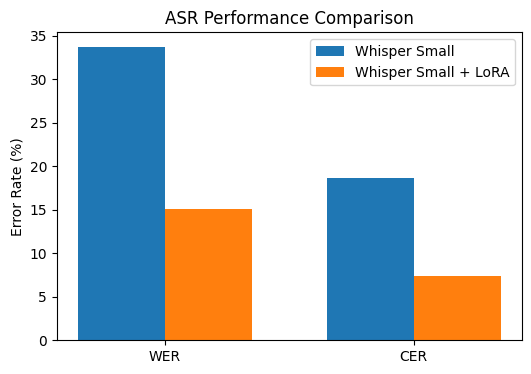

In [33]:
import matplotlib.pyplot as plt

metrics = ["WER", "CER"]
base = [33.70, 18.70]
ft = [15.10, 7.43]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar([i-width/2 for i in x], base, width, label="Whisper Small")
plt.bar([i+width/2 for i in x], ft, width, label="Whisper Small + LoRA")

plt.xticks(x, metrics)
plt.ylabel("Error Rate (%)")
plt.title("ASR Performance Comparison")
plt.legend()
plt.show()

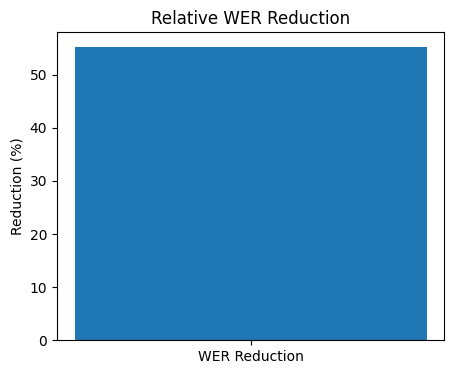

In [34]:
reduction = (33.70 - 15.10)/33.70*100

plt.figure(figsize=(5,4))
plt.bar(["WER Reduction"], [reduction])

plt.ylabel("Reduction (%)")
plt.title("Relative WER Reduction")
plt.show()

In [35]:
plt.figure(figsize=(8,4))

plt.hist(base_wers,
         bins=50,
         alpha=0.5,
         label="Base")

plt.hist(ft_wers,
         bins=50,
         alpha=0.5,
         label="LoRA")

plt.xlabel("WER")
plt.ylabel("Samples")
plt.legend()
plt.show()

NameError: name 'base_wers' is not defined

<Figure size 800x400 with 0 Axes>

In [36]:
!zip -r whisper-vimer-lora-chunk5.zip /kaggle/working/whisper-vimer-lora-chunk5

  adding: kaggle/working/whisper-vimer-lora-chunk5/ (stored 0%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoint-1000/ (stored 0%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoint-1000/scaler.pt (deflated 64%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoint-1000/adapter_model.safetensors (deflated 7%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoint-1000/rng_state.pth (deflated 26%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoint-1000/trainer_state.json (deflated 75%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoint-1000/preprocessor_config.json (deflated 42%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoint-1000/adapter_config.json (deflated 59%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoint-1000/README.md (deflated 66%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoint-1000/training_args.bin (deflated 53%)
  adding: kaggle/working/whisper-vimer-lora-chunk5/checkpoi